---
title: "Notebook writing style: a demonstration"
date: "2026-08-13"
categories: []
---

Maximum likelihood estimation — the method of finding the parameter value that makes the observed data most probable — is the workhorse of statistical inference. This note derives the [maximum likelihood estimator]{.mark} for the upper bound of a [uniform distribution](https://en.wikipedia.org/wiki/Continuous_uniform_distribution), contrasting it with a simpler but flawed alternative.

The derivation exercises every element of the watchtower notebook style: action-first prose, impersonal voice, counter-example before correct approach, display math with boxed results, tables for comparison, and code cells with numbered annotations. Read it both as a statistics lesson and as a style reference.


**The model.** Let $X_1, \ldots, X_n \stackrel{\text{iid}}{\sim} \text{Uniform}(0, \theta)$ where $\theta > 0$ is the unknown upper bound. The density is

$$
f(x; \theta) = \begin{cases} 1/\theta & \text{if } 0 \le x \le \theta \\ 0 & \text{otherwise} \end{cases}
$$

The population mean is $\mathbb{E}[X] = \theta / 2$ and the variance is $\text{Var}(X) = \theta^2 / 12$. Both depend on $\theta$ alone, so a single parameter governs the entire distribution.


**Synthetic data.** Draw 50 samples from $\text{Uniform}(0, 5)$ to serve as ground truth throughout:


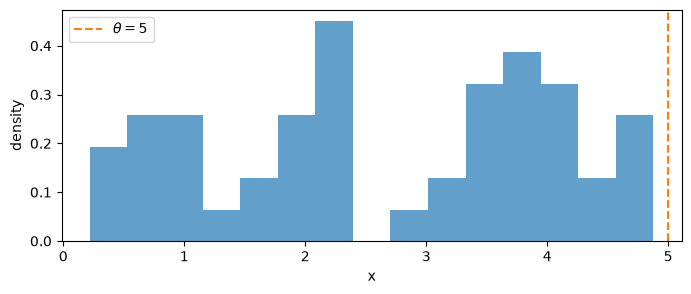

n = 50, true theta = 5.0
sample mean = 2.6762
sample max  = 4.8781


In [1]:
#| label: fig-histogram
#| cap: "**Synthetic sample.** Fifty draws from Uniform(0, 5) plotted as a histogram. The dashed line marks the true upper bound; the rightmost bar falls short of it, illustrating the structural gap between max(x) and theta."
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
theta_true = 5.0
n = 50
data = rng.uniform(0, theta_true, size=n)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(data, bins=15, density=True, alpha=0.7, color="C0")
ax.axvline(theta_true, color="C1", linestyle="--", label=r"$\theta = 5$")
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.legend()
plt.show()

print(f"n = {n}, true theta = {theta_true}")
print(f"sample mean = {data.mean():.4f}")
print(f"sample max  = {data.max():.4f}")


The sample mean overshoots $\theta/2 = 2.5$ and the sample max undershoots $\theta = 5$ — two deviations in opposite directions. The max gap is structural, not noise: the maximum of $n$ uniform draws concentrates below $\theta$, and the gap shrinks as $n$ grows. This observation motivates two competing estimators, one of which exploits it directly.

**A naive estimator: method of moments.** The [method of moments](https://en.wikipedia.org/wiki/Method_of_moments_(statistics)) equates the sample mean $\bar{x}$ to the population mean $\mathbb{E}[X] = \theta/2$ and solves for $\theta$:

$$
\hat{\theta}_{\text{MoM}} = 2\bar{x} = \frac{2}{n}\sum_{i=1}^{n} x_i
$$

This estimator is [unbiased]{.underline} — $\mathbb{E}[\hat{\theta}_{\text{MoM}}] = \theta$ — but it can produce impossible values. Since every $x_i \le \theta$, any valid estimate must satisfy $\hat{\theta} \ge \max(x_i)$. Yet $2\bar{x}$ can fall below $\max(x_i)$ when the sample skews toward the upper bound, yielding an estimate that the data itself contradicts.


Compute the method-of-moments estimate and check whether it respects the constraint $\hat{\theta} \ge \max(x_i)$:


In [2]:
theta_mom = 2 * data.mean()
x_max = data.max()

print(f"theta_MoM  = 2*x_bar = {theta_mom:.4f}")
print(f"max(x)              = {x_max:.4f}")
print(f"valid (theta >= max)? {theta_mom >= x_max}")


theta_MoM  = 2*x_bar = 5.3523
max(x)              = 4.8781
valid (theta >= max)? True


**The likelihood.** The joint density of the sample — the [likelihood function]{.mark} — is

$$
L(\theta) = \prod_{i=1}^{n} f(x_i; \theta) = \frac{1}{\theta^n} \cdot \mathbb{1}\!\left[\max(x_i) \le \theta\right]
$$

where the indicator $\mathbb{1}[\cdot]$ enforces the support constraint. The log-likelihood is

$$
\ell(\theta) = -n \log \theta + \log \mathbb{1}\!\left[\max(x_i) \le \theta\right]
$$

For $\theta \ge \max(x_i)$, the indicator is 1 and $\ell(\theta) = -n\log\theta$, which is strictly decreasing in $\theta$. For $\theta < \max(x_i)$, the likelihood is zero. The maximum therefore occurs at the smallest admissible $\theta$:

$$
\boxed{\hat{\theta}_{\text{MLE}} = \max(x_i)}
$$

The MLE is always feasible (it never falls below $\max(x_i)$), but it is [biased]{.underline}: $\mathbb{E}[\max(x_i)] = \frac{n}{n+1}\theta$, so the estimator systematically undershoots $\theta$. A bias-corrected variant scales by $\frac{n+1}{n}$:[^bias]

$$
\hat{\theta}_{\text{corr}} = \frac{n+1}{n} \cdot \max(x_i)
$$

[^bias]: The maximum of $n$ iid $\text{Uniform}(0,\theta)$ draws follows $\frac{\max(x_i)}{\theta} \sim \text{Beta}(n, 1)$, whose mean is $n/(n+1)$. Hence $\mathbb{E}[\max(x_i)] = \frac{n}{n+1}\theta$.


Compute all three estimators and compare them against the true $\theta = 5$:


In [3]:
theta_mle = data.max()                              # <1>
theta_corr = (n + 1) / n * data.max()               # <2>

print(f"true theta      = {theta_true:.4f}")
print(f"theta_MoM       = {theta_mom:.4f}  (unbiased, can be infeasible)")
print(f"theta_MLE       = {theta_mle:.4f}  (feasible, biased)")
print(f"theta_corrected = {theta_corr:.4f}  (feasible, unbiased)")


true theta      = 5.0000
theta_MoM       = 5.3523  (unbiased, can be infeasible)
theta_MLE       = 4.8781  (feasible, biased)
theta_corrected = 4.9757  (feasible, unbiased)


The annotations in the preceding cell mark two distinct operations: (1) takes the raw maximum as the MLE, exploiting the support constraint directly; (2) applies the bias correction $\frac{n+1}{n}$ derived above.

| Estimator | Formula | Bias | Feasible? |
|---|---|---|---|
| Method of moments | $2\bar{x}$ | None | Not always |
| MLE | $\max(x_i)$ | $\frac{-\theta}{n+1}$ | Always |
| Corrected MLE | $\frac{n+1}{n}\max(x_i)$ | None | Always |

The corrected MLE dominates the field: it is unbiased and always feasible. The MLE itself is biased but [consistent]{.underline} — the bias vanishes as $n \to \infty$ since $\frac{n}{n+1} \to 1$.

:::{.callout-note}
The bias-variance tradeoff here is atypical. The MLE has lower variance than the corrected version (scaling inflates spread), so for mean-squared error, the raw MLE can outperform the corrected estimator at small $n$. Bias correction is not always the right call.
:::


**Summary.** Three estimators, one parameter:

| Approach | Key idea | When to use |
|---|---|---|
| Method of moments | Match sample and population moments | Quick estimates, large $n$ |
| Maximum likelihood | Maximize the data probability | General-purpose, asymptotically efficient |
| Bias-corrected MLE | Adjust MLE for finite-sample bias | When unbiasedness matters more than MSE |

The uniform-bound problem is a microcosm of the broader MLE methodology: write the likelihood, exploit the support, and check the bias. The same three-step recipe scales to models where no closed-form solution exists — numerical optimization replaces the analytic step, but the logic is identical.
